In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import datetime as dt
from datetime import timedelta
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors

In [3]:
data = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
data.dropna(subset=['Customer ID'], inplace=True)

In [6]:
data['Order Date']=pd.to_datetime(data['Order Date'])
data['Total Amount']= data['Sales']

In [7]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total Amount
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,261.9600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,731.9400
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,14.6200
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,957.5775
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,22.3680


In [8]:
refernce_date = pd.Timestamp(dt.datetime.now().date())

In [9]:
refernce_date

Timestamp('2026-04-25 00:00:00')

In [10]:
reference_date= data['Order Date'].max() + timedelta(days=1)

In [11]:
reference_date

Timestamp('2017-12-31 00:00:00')

In [12]:
rfm= data.groupby('Customer ID').agg({
    'Order Date': lambda x : (reference_date - x.max()).days,
    'Order ID':'count',
    'Total Amount':'sum'
})

In [13]:
rfm.rename(columns={'Order Date':'Recency', 'Order ID':'Frequency', 'Total Amount':'Monetary'}, inplace=True)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,11,5563.560
AA-10375,20,15,1056.390
AA-10480,260,12,1790.512
AA-10645,56,18,5086.935
AB-10015,416,6,886.156


In [14]:
#### Define quantiles
quantiles = rfm.quantile(q=[0.25, 0.5, 0.75])

# Assign RFM scores
def RScore(x, p, d):
    if p == 'Recency':
        if x <= d[p][0.25]:
            return 4
        elif x <= d[p][0.50]:
            return 3
        elif x <= d[p][0.75]:
            return 2
        else:
            return 1
    else:
        if x <= d[p][0.25]:
            return 1
        elif x <= d[p][0.50]:
            return 2
        elif x <= d[p][0.75]:
            return 3
        else:
            return 4
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency', quantiles))
rfm['F'] = rfm['Frequency'].apply(RScore, args=('Frequency', quantiles))
rfm['M'] = rfm['Monetary'].apply(RScore, args=('Monetary', quantiles))

rfm.head()

,Recency,Frequency,Monetary,R,F,M
Customer ID,,,,,,
AA-10315,185,11,5563.560,1,2,4
AA-10375,20,15,1056.390,4,3,1
AA-10480,260,12,1790.512,1,2,2
AA-10645,56,18,5086.935,3,4,4
AB-10015,416,6,886.156,1,1,1


In [15]:
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [16]:
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

In [17]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
Customer ID,,,,,,,,
AA-10315,185,11,5563.560,1,2,4,124,7
AA-10375,20,15,1056.390,4,3,1,431,8
AA-10480,260,12,1790.512,1,2,2,122,5
AA-10645,56,18,5086.935,3,4,4,344,11
AB-10015,416,6,886.156,1,1,1,111,3


In [18]:
segment_label=['low_level','mid level','high value']

In [20]:
def segment(row):
    if row['RFM_Score'] >= 9:
        return 'High Value'
    elif row['RFM_Score'] >= 5:
        return 'Mid Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,Segment
Customer ID,,,,,,,,,
AA-10315,185,11,5563.560,1,2,4,124,7,Mid Value
AA-10375,20,15,1056.390,4,3,1,431,8,Mid Value
AA-10480,260,12,1790.512,1,2,2,122,5,Mid Value
AA-10645,56,18,5086.935,3,4,4,344,11,High Value
AB-10015,416,6,886.156,1,1,1,111,3,Low Value


In [21]:
rfm['Segment'].value_counts().reset_index()

,Segment,count
0,Mid Value,371
1,High Value,300
2,Low Value,122


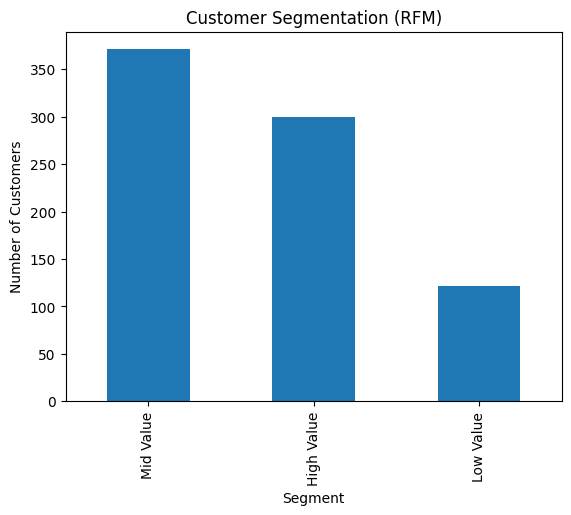

In [22]:
import matplotlib.pyplot as plt

# Count segments
segment_counts = rfm['Segment'].value_counts()

# Plot
plt.figure()
segment_counts.plot(kind='bar')

# Labels & title
plt.title('Customer Segmentation (RFM)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

# Show plot
plt.show()

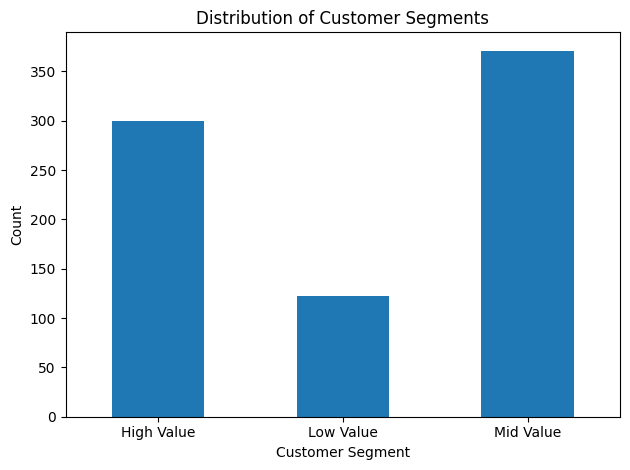

In [23]:
plt.figure()
rfm['Segment'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Count')

plt.xticks(rotation=0)  # keeps labels straight
plt.tight_layout()

plt.show()

In [24]:
total_customers = len(rfm)

high = len(rfm[rfm['Segment'] == 'High Value'])
mid = len(rfm[rfm['Segment'] == 'Mid Value'])
low = len(rfm[rfm['Segment'] == 'Low Value'])

print("High Value Customers:", high)
print("Mid Value Customers:", mid)
print("Low Value Customers:", low)

print("\nPercentages:")
print("High Value %:", round(high/total_customers*100,2))
print("Mid Value %:", round(mid/total_customers*100,2))
print("Low Value %:", round(low/total_customers*100,2))

High Value Customers: 300
Mid Value Customers: 371
Low Value Customers: 122

Percentages:
High Value %: 37.83
Mid Value %: 46.78
Low Value %: 15.38


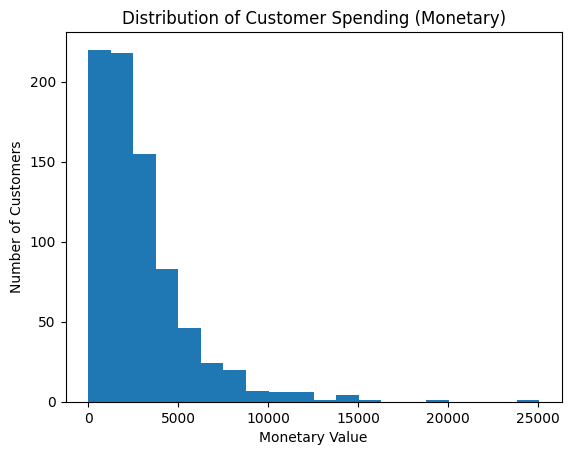

In [26]:
import matplotlib.pyplot as plt

plt.figure()

rfm['Monetary'].plot(kind='hist', bins=20)

plt.title('Distribution of Customer Spending (Monetary)')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')

plt.show()

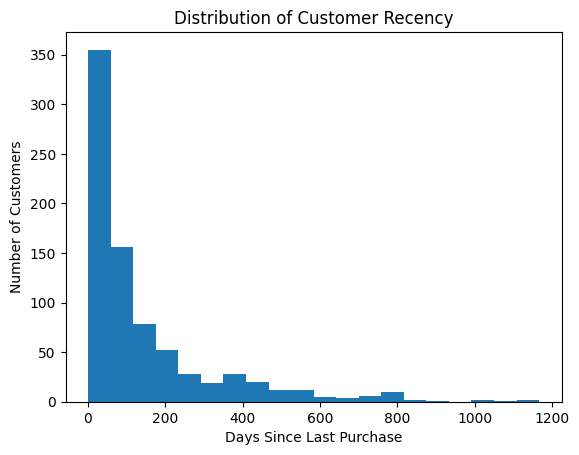

In [27]:
plt.figure()

rfm['Recency'].plot(kind='hist', bins=20)

plt.title('Distribution of Customer Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.show()

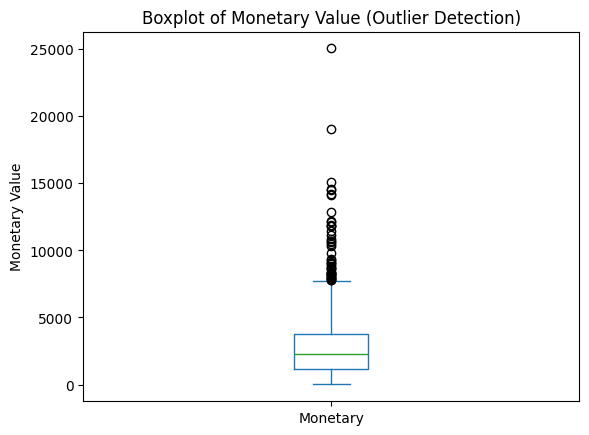

In [28]:
import matplotlib.pyplot as plt

plt.figure()

rfm['Monetary'].plot(kind='box')

plt.title('Boxplot of Monetary Value (Outlier Detection)')
plt.ylabel('Monetary Value')

plt.show()

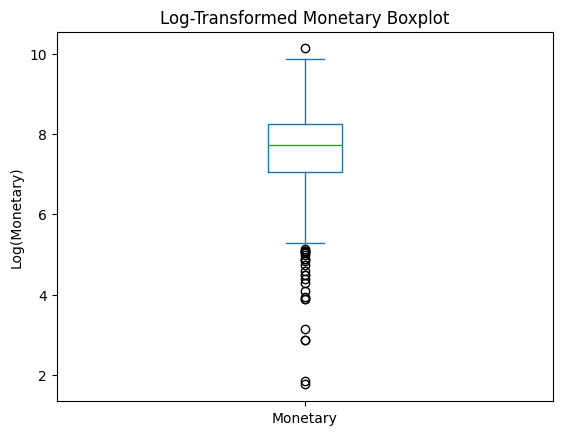

In [29]:
import numpy as np

plt.figure()

np.log1p(rfm['Monetary']).plot(kind='box')

plt.title('Log-Transformed Monetary Boxplot')
plt.ylabel('Log(Monetary)')

plt.show()